<a href="https://colab.research.google.com/github/armakoua-a11y/colab-git-Lesson_14_assignment_14-AK/blob/main/Assignment14_Ethical_AI_Explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 14: Ethical AI Analysis and Explainability



In [1]:
!pip install -q fairlearn shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 5.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, true_positive_rate

import shap
from lime.lime_tabular import LimeTabularExplainer

np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 1. Dataset Preparation

**Dataset:** the classic Titanic passenger dataset (public, via the `seaborn-data` GitHub mirror). It is a standard dataset for teaching fairness analysis because historical survival rates differed sharply by **sex** ("women and children first"), giving us a real, interpretable sensitive attribute to audit.

- **Target (y):** `survived` (0 = did not survive, 1 = survived)
- **Features (X):** `pclass`, `age`, `sibsp`, `parch`, `fare`, `sex`, `embarked`
- **Sensitive attribute:** `sex` (male / female)

In [3]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)
print("Raw shape:", df.shape)
df.head()

Raw shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
target = "survived"
sensitive_attr = "sex"

data = df[features + [target]].copy()

# Handle missing values
data["age"] = data["age"].fillna(data["age"].median())
data["embarked"] = data["embarked"].fillna(data["embarked"].mode()[0])
data["fare"] = data["fare"].fillna(data["fare"].median())

# Keep a readable copy of the sensitive attribute for fairness reporting
sensitive_series = data[sensitive_attr].copy()

# One-hot encode categorical features
data_encoded = pd.get_dummies(data, columns=["sex", "embarked"], drop_first=True)

X = data_encoded.drop(columns=[target])
y = data_encoded[target]

print("Feature columns:", list(X.columns))
print("\nClass balance (survived):")
print(y.value_counts(normalize=True))

Feature columns: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S']

Class balance (survived):
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


## 2. Model Training and Evaluation

In [5]:
X_train, X_test, y_train, y_test, sens_train, sens_test = train_test_split(
    X, y, sensitive_series, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print("Model trained.")

Model trained.


In [6]:
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report_text = classification_report(y_test, y_pred)

print(f"Accuracy: {acc:.4f}\n")
print("Confusion matrix:")
print(cm)
print()
print(report_text)

Accuracy: 0.7713

Confusion matrix:
[[113  24]
 [ 27  59]]

              precision    recall  f1-score   support

           0       0.81      0.82      0.82       137
           1       0.71      0.69      0.70        86

    accuracy                           0.77       223
   macro avg       0.76      0.76      0.76       223
weighted avg       0.77      0.77      0.77       223



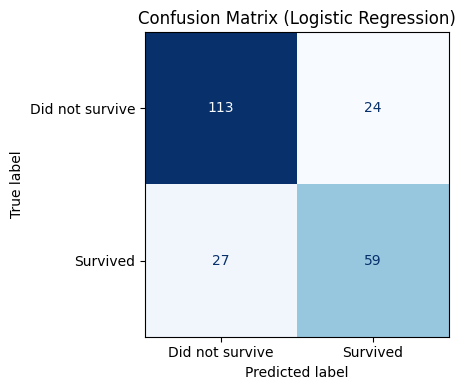

In [7]:
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Did not survive", "Survived"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix (Logistic Regression)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

**Findings:** The model reaches roughly 77% test accuracy, with somewhat higher precision for predicting non-survival than survival — consistent with the class imbalance (about 62% did not survive). Accuracy alone, however, says nothing about whether the model treats male and female passengers equitably, which is exactly what the fairness analysis below investigates.

## 3. Fairness Analysis (Fairlearn)

We use Fairlearn's `MetricFrame` to compute accuracy, **selection rate** (fraction predicted to survive), **false positive rate**, and **true positive rate**, broken out by the sensitive attribute `sex`.

In [8]:
metrics = {
    "accuracy": accuracy_score,
    "selection_rate": selection_rate,
    "false_positive_rate": false_positive_rate,
    "true_positive_rate": true_positive_rate,
}

mf = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sens_test,
)

print("Metrics by group:")
print(mf.by_group)
print("\nDifference (max - min across groups):")
print(mf.difference())
print("\nRatio (min / max across groups):")
print(mf.ratio())

Metrics by group:
        accuracy  selection_rate  false_positive_rate  true_positive_rate
sex                                                                      
female  0.750000        0.887500             0.739130            0.947368
male    0.783217        0.083916             0.061404            0.172414

Difference (max - min across groups):
accuracy               0.033217
selection_rate         0.803584
false_positive_rate    0.677727
true_positive_rate     0.774955
dtype: float64

Ratio (min / max across groups):
accuracy               0.957589
selection_rate         0.094553
false_positive_rate    0.083075
true_positive_rate     0.181992
dtype: float64


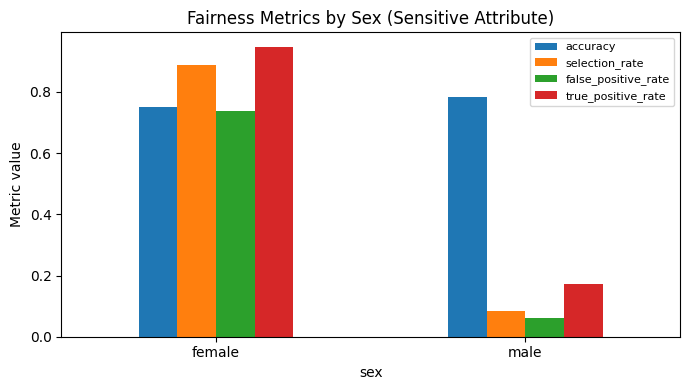

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
mf.by_group.plot.bar(ax=ax)
ax.set_title("Fairness Metrics by Sex (Sensitive Attribute)")
ax.set_ylabel("Metric value")
ax.legend(loc="upper right", fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("fairness_by_group.png", dpi=150)
plt.show()

**Key findings:** The disparity is large. The model predicts survival for roughly **89% of female passengers vs. ~8% of male passengers** (selection rate), and true positive rate is far higher for women (~95%) than men (~17%). This is not necessarily a *model bug* — it reflects a genuine, strong historical pattern in who survived the Titanic — but it is exactly the kind of large, systematic outcome gap across a sensitive attribute that a fairness audit is designed to surface, and it would be unacceptable if this same pattern showed up in, say, a hiring or lending model rather than a historical-disaster dataset. It illustrates why fairness metrics must always be interpreted together with domain context.

## 4. Explainability Analysis (SHAP + LIME)

### Global explainability: SHAP summary plot
SHAP (SHapley Additive exPlanations) assigns each feature a contribution value for every prediction, grounded in cooperative game theory (Shapley values). Aggregating these across all test instances shows global feature importance and directionality.

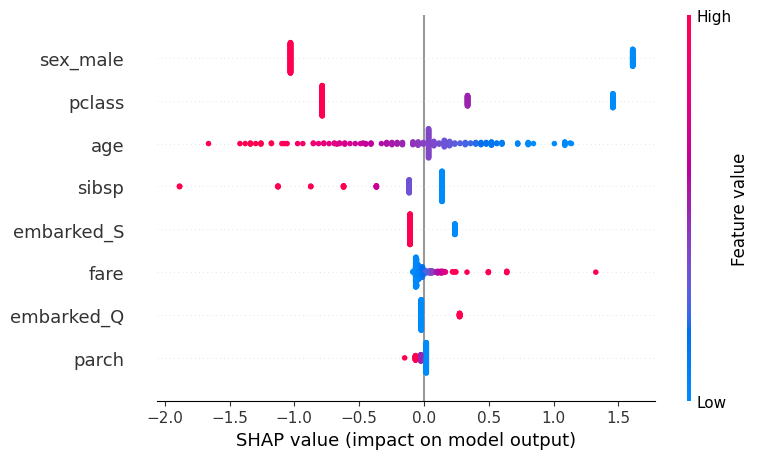

In [10]:
explainer = shap.LinearExplainer(model, X_train_scaled)
shap_values = explainer(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** `sex_male` and `pclass` are the strongest drivers of predicted survival — being male and traveling in a lower passenger class both push predictions toward "did not survive" (consistent with historical accounts), while lower `age` and higher `fare` push predictions toward survival.

### Local explainability: SHAP waterfall plot

A waterfall plot breaks down **one individual prediction** into the additive contribution of each feature, starting from the model's base (average) prediction.

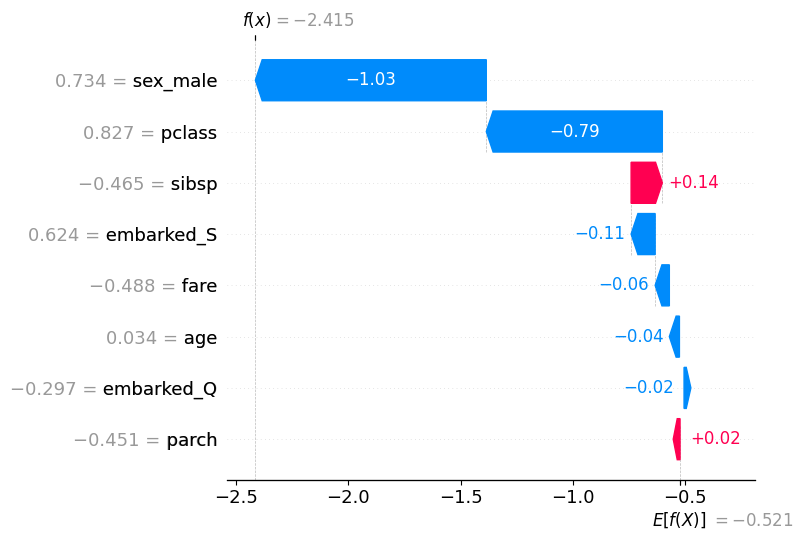

True label: 0 | Predicted label: 0
Sensitive attribute (sex) for this passenger: male


In [11]:
instance_idx = 0
shap.plots.waterfall(shap_values[instance_idx], show=False)
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

print("True label:", y_test.iloc[instance_idx], "| Predicted label:", y_pred[instance_idx])
print("Sensitive attribute (sex) for this passenger:", sens_test.iloc[instance_idx])

### Local explainability: LIME

LIME (Local Interpretable Model-agnostic Explanations) fits a simple, interpretable surrogate model around a single prediction to explain it, independent of the underlying model type — useful as a cross-check against SHAP's explanation for the same instance.

LIME explanation for the same test instance:
  -0.38 < pclass <= 0.83: -0.2787
  -1.36 < sex_male <= 0.73: -0.1427
  embarked_Q <= -0.30: -0.0507
  sibsp <= -0.46: +0.0370
  -0.12 < age <= 0.50: -0.0336
  -1.60 < embarked_S <= 0.62: -0.0161
  -0.49 < fare <= -0.37: -0.0155


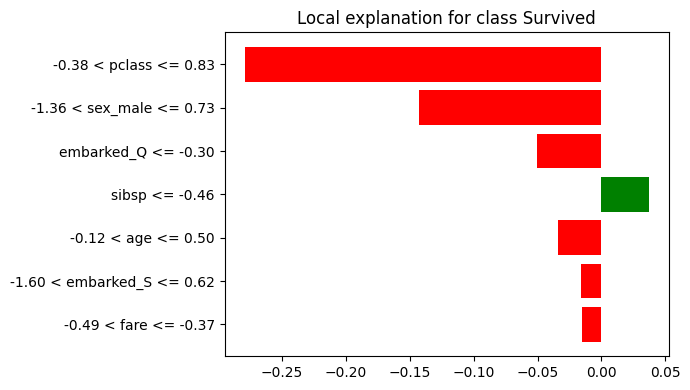

In [12]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train_scaled.values,
    feature_names=list(X_train_scaled.columns),
    class_names=["Did not survive", "Survived"],
    mode="classification",
    random_state=42,
)

lime_exp = lime_explainer.explain_instance(
    X_test_scaled.values[instance_idx],
    model.predict_proba,
    num_features=7,
)

print("LIME explanation for the same test instance:")
for feat, weight in lime_exp.as_list():
    print(f"  {feat}: {weight:+.4f}")

fig = lime_exp.as_pyplot_figure()
fig.set_size_inches(7, 4)
plt.tight_layout()
plt.savefig("lime_explanation.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** LIME agrees with SHAP that `pclass` and `sex_male` are the dominant negative contributors for this passenger's survival prediction, giving us two independent explanation methods pointing to the same conclusion — a useful sanity check when auditing a model.

## 5. Ethical Considerations and Recommendations

- **Historical bias vs. harmful bias:** the large gender gap here mirrors
  genuine historical events (evacuation priority), which is different
  from a model *learning* an unjust pattern from biased real-world
  decisions (e.g., biased past hiring or lending decisions). Both
  produce the same fairness-metric signature, so metrics alone cannot
  distinguish "correctly modeling a real historical process" from
  "reproducing an unjust pattern" — domain judgment is required.
- **Choice of fairness criterion matters:** selection-rate parity
  (demographic parity), equal true-positive-rate (equal opportunity),
  and equal false-positive-rate are different, sometimes
  mutually-incompatible fairness definitions; teams must explicitly
  choose which is appropriate for their use case rather than assuming
  one metric is "the" fairness metric.
- **Sensitive attributes may be encoded indirectly:** even without a
  `sex` column, correlated features (e.g., titles, cabin patterns) can
  let a model reconstruct sensitive information, so removing a sensitive
  column is not sufficient on its own to prevent disparate treatment.
- **Explainability supports accountability:** SHAP and LIME let
  stakeholders see *why* a model made a decision, which is a
  precondition for contesting or correcting unfair outcomes, and both
  should be used together since they can catch different issues.
- **Recommendations for improving fairness:** apply fairness-aware
  training constraints (e.g., Fairlearn's `ExponentiatedGradient` or
  `ThresholdOptimizer`) when parity is actually the goal; report
  disaggregated metrics (not just overall accuracy) in every model
  evaluation; document the sensitive attributes considered and the
  fairness definition chosen; and pair automated audits with human
  review before deployment in any consequential decision.


## 6. Conclusion

This notebook built a logistic regression classifier, evaluated it with
standard performance metrics, then audited it along two axes: **fairness**
(Fairlearn's MetricFrame revealed large disparities in selection rate and
true-positive rate across sex) and **explainability** (SHAP's global
summary and local waterfall plots, cross-checked with LIME, revealed
`sex` and `pclass` as the dominant drivers of individual predictions).
Together, these tools move a model from an opaque black box toward
something stakeholders can inspect, question, and hold accountable.
Future improvements could include fairness-constrained training,
testing multiple/intersectional sensitive attributes (e.g., sex combined
with class), and extending the explainability analysis to a
non-linear model (e.g., gradient boosting) using SHAP's `TreeExplainer`.
